<a href="https://colab.research.google.com/github/JMCVALE/ASN-ROCKS-/blob/main/SVM_TIPOS_KERNEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TESTAR DIFERENTES TIPOS DE KERNEL**

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from sklearn.svm import SVC

np.random.seed(100)


In [3]:
# Parâmetros
m1 = np.array([1, 5])
m0 = np.array([5, 2])

s1 = 1
s0 = 1
rho = 0.0 * s1 * s0

pi1 = 0.05
pi0 = 1 - pi1
n = 500

Sigma = np.array([[s1, rho],
                  [rho, s0]])

# Amostras
n1 = int(n * pi1)
n0 = int(n * pi0)

x1 = multivariate_normal.rvs(mean=m1, cov=Sigma, size=n1)
x0 = multivariate_normal.rvs(mean=m0, cov=Sigma, size=n0)

# Labels
Y = np.concatenate([np.ones(n1), -np.ones(n0)])
X = np.vstack([x1, x0])

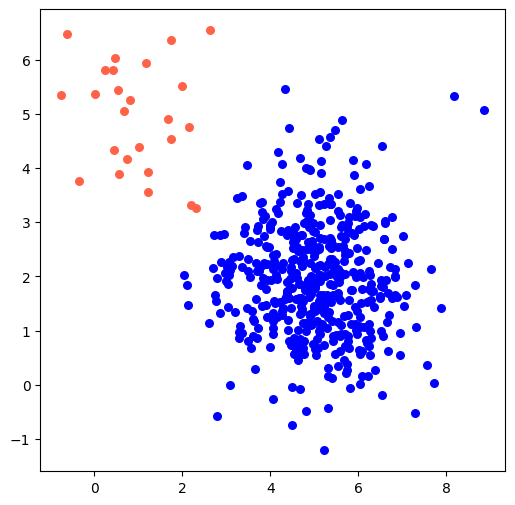

In [4]:
plt.figure(figsize=(6, 6))
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], color="tomato", s=30)
plt.scatter(X[Y == -1, 0], X[Y == -1, 1], color="blue", s=30)
plt.show()

KERNEL GAUSSIANO

In [15]:
np.random.seed(1)

model = SVC(
    kernel="rbf",
    C=1
)

model.fit(X, Y)

SVC(C=1)

In [16]:
x1_seq = np.linspace(-2, 8, 100)
x2_seq = np.linspace(-2, 8, 100)

xx1, xx2 = np.meshgrid(x1_seq, x2_seq)
grid = np.c_[xx1.ravel(), xx2.ravel()]

Y_fit = model.predict(grid)

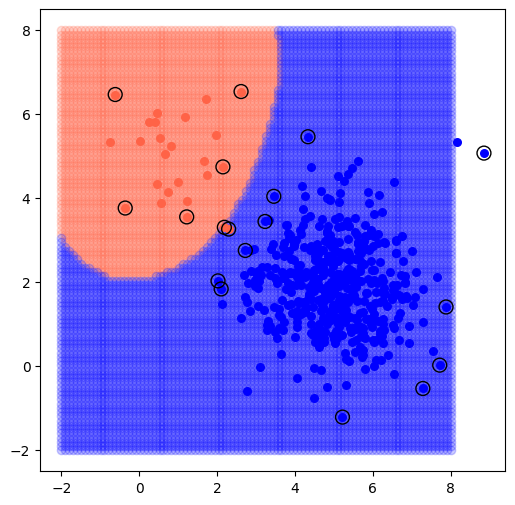

In [17]:
plt.figure(figsize=(6, 6))

# Fronteira de decisão
plt.scatter(
    grid[Y_fit == 1, 0],
    grid[Y_fit == 1, 1],
    color="tomato",
    alpha=0.2
)

plt.scatter(
    grid[Y_fit == -1, 0],
    grid[Y_fit == -1, 1],
    color="blue",
    alpha=0.2
)

# Dados originais
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], color="tomato", s=30)
plt.scatter(X[Y == -1, 0], X[Y == -1, 1], color="blue", s=30)

# Vetores de suporte (equivalente ao alphaindex do kernlab)
sv = model.support_
plt.scatter(
    X[sv, 0],
    X[sv, 1],
    facecolors="none",
    edgecolors="black",
    s=100
)

plt.show()

In [19]:
model.support_

array([ 51,  60, 110, 169, 249, 253, 264, 297, 359, 412, 429,   1,  10,
        15,  18,  19,  22,  24], dtype=int32)

In [20]:
np.abs(model.dual_coef_).flatten()

array([1.        , 1.        , 0.85739678, 0.23915976, 1.        ,
       0.41875056, 0.28619061, 0.75351666, 0.2310634 , 0.01996081,
       0.15041807, 1.        , 1.        , 1.        , 1.        ,
       0.16323372, 1.        , 0.79322293])

COMPARAÇÃO DE KERNELS

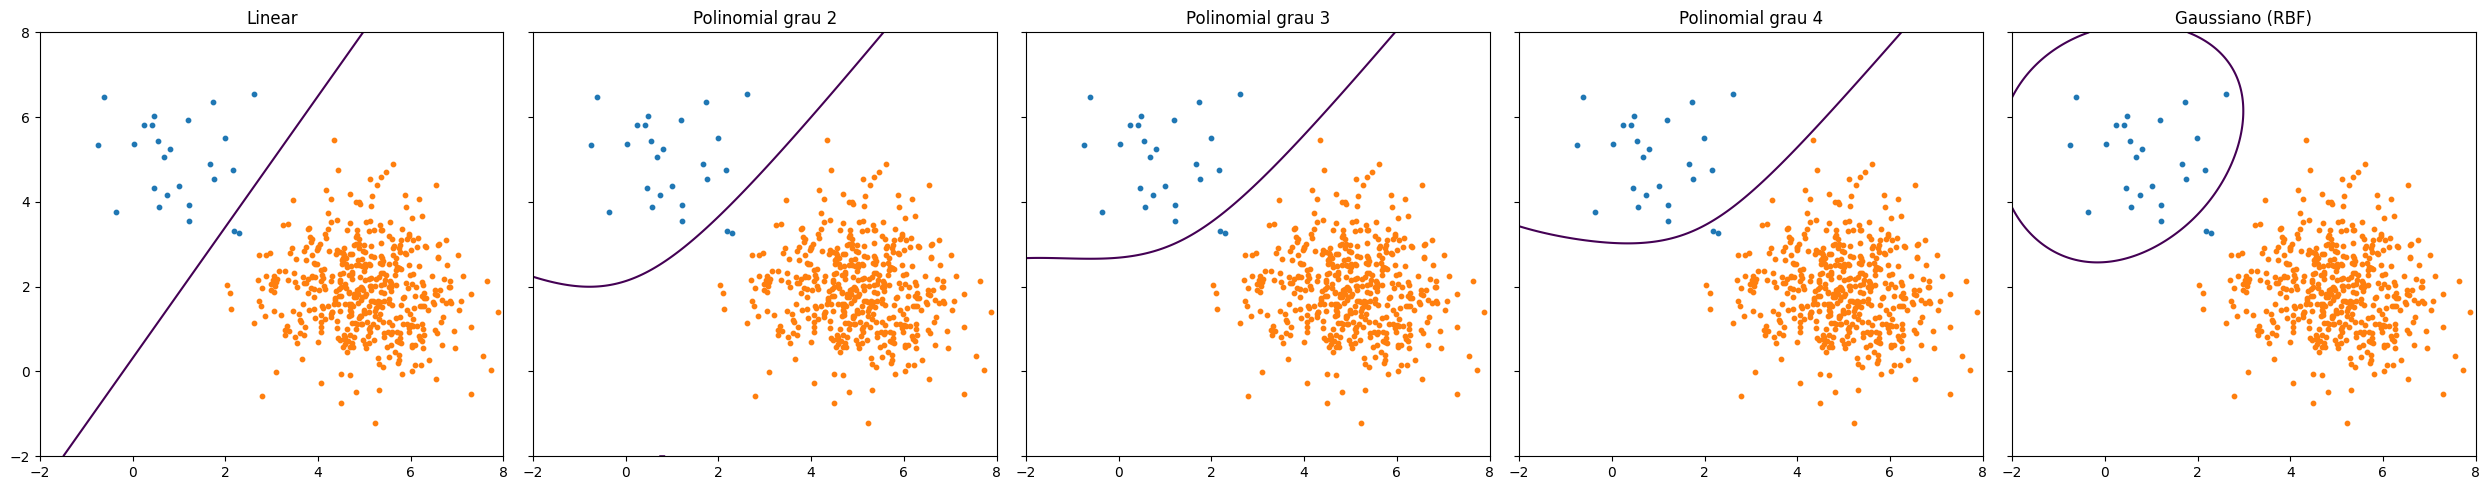

In [12]:
# -------------------------------
# MODELOS
# -------------------------------
models = [
    ("Linear", SVC(kernel="linear", C=0.1)),
    ("Polinomial grau 2", SVC(kernel="poly", degree=2, C=0.1)),
    ("Polinomial grau 3", SVC(kernel="poly", degree=3, C=0.1)),
    ("Polinomial grau 4", SVC(kernel="poly", degree=4, C=0.1)),
    ("Gaussiano (RBF)", SVC(kernel="rbf", C=0.1))
]

# -------------------------------
# PLOTS LADO A LADO
# -------------------------------
fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharex=True, sharey=True)

for ax, (title, model) in zip(axes, models):
    model.fit(X, y)
    Z = model.decision_function(grid).reshape(xx1.shape)

    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=10)
    ax.scatter(X[y == -1, 0], X[y == -1, 1], s=10)
    ax.contour(xx1, xx2, Z, levels=[0])

    ax.set_title(title)
    ax.set_xlim(-2, 8)
    ax.set_ylim(-2, 8)

plt.tight_layout()
plt.show()


COMPARAÇÃO DE C

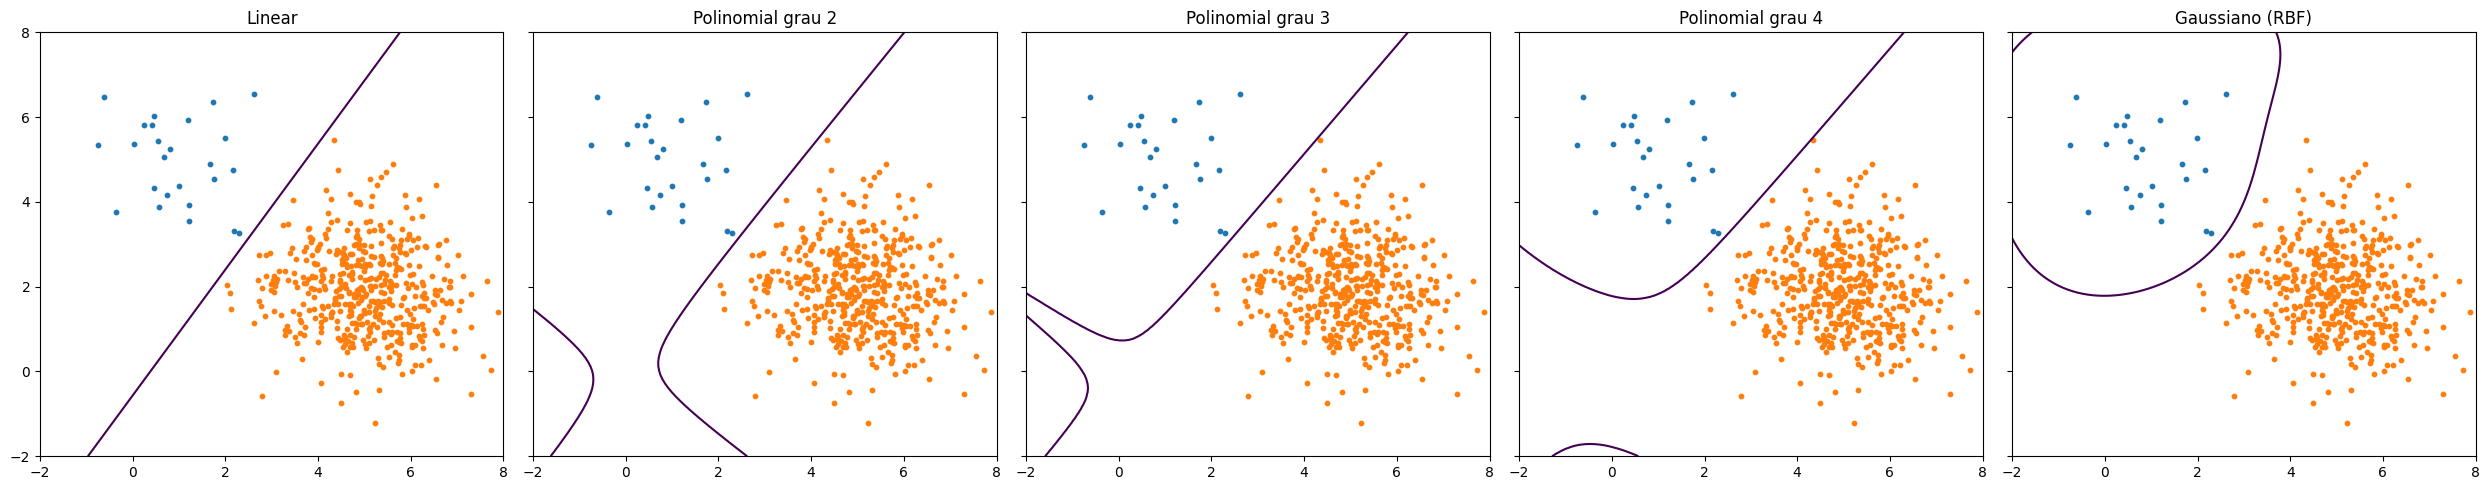

In [21]:
# -------------------------------
# MODELOS
# -------------------------------
models = [
    ("Linear", SVC(kernel="linear", C=10)),
    ("Polinomial grau 2", SVC(kernel="poly", degree=2, C=10)),
    ("Polinomial grau 3", SVC(kernel="poly", degree=3, C=10)),
    ("Polinomial grau 4", SVC(kernel="poly", degree=4, C=10)),
    ("Gaussiano (RBF)", SVC(kernel="rbf", C=10))
]

# -------------------------------
# PLOTS LADO A LADO
# -------------------------------
fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharex=True, sharey=True)

for ax, (title, model) in zip(axes, models):
    model.fit(X, y)
    Z = model.decision_function(grid).reshape(xx1.shape)

    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=10)
    ax.scatter(X[y == -1, 0], X[y == -1, 1], s=10)
    ax.contour(xx1, xx2, Z, levels=[0])

    ax.set_title(title)
    ax.set_xlim(-2, 8)
    ax.set_ylim(-2, 8)

plt.tight_layout()
plt.show()

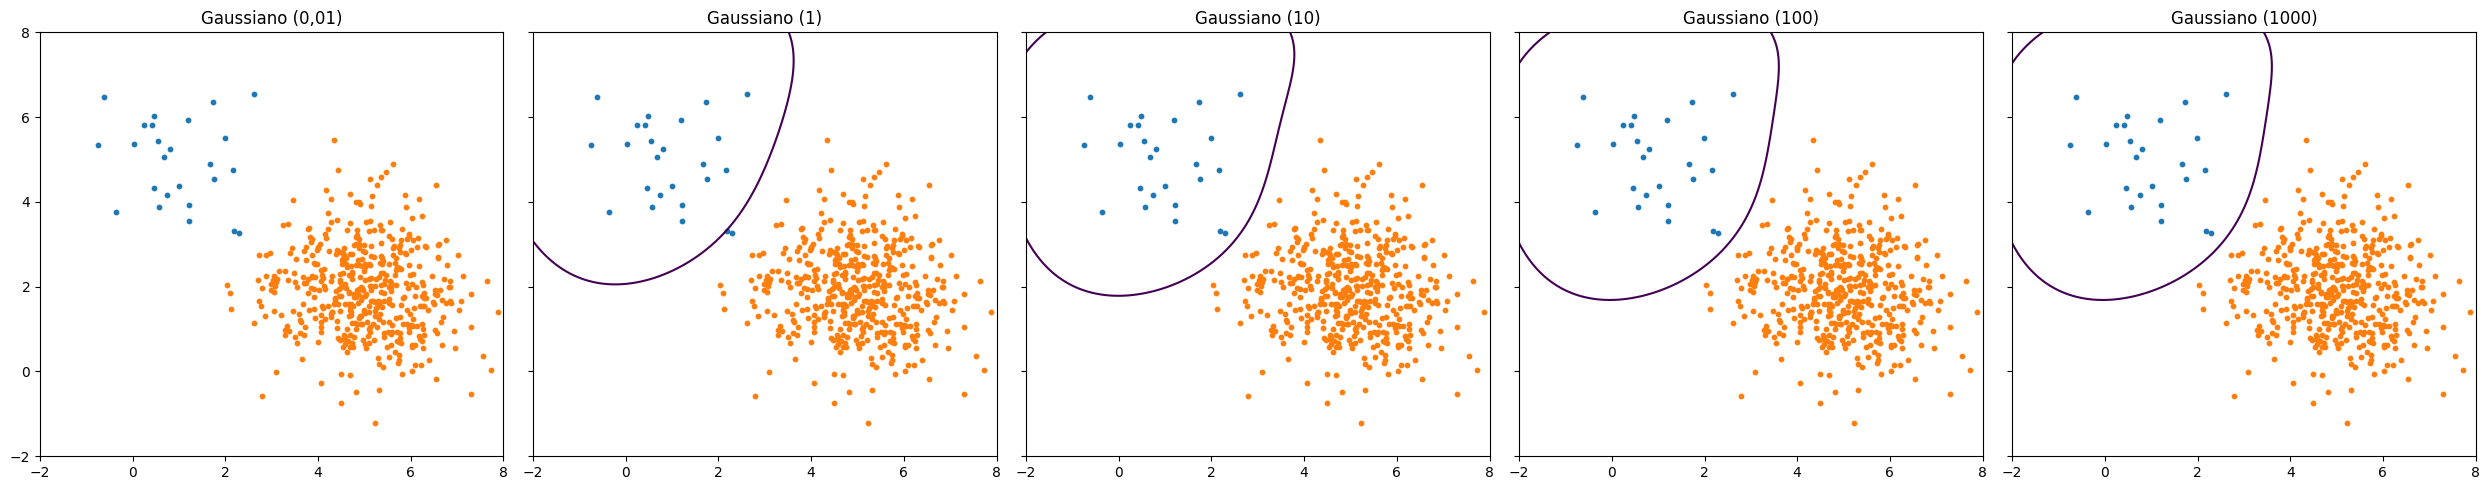

In [25]:
models = [
    ("Gaussiano (0,01)", SVC(kernel="rbf", C=0.01)),
    ("Gaussiano (1)", SVC(kernel="rbf", C=1)),
    ("Gaussiano (10)", SVC(kernel="rbf", C=10)),
    ("Gaussiano (100)", SVC(kernel="rbf", C=100)),
    ("Gaussiano (1000)", SVC(kernel="rbf", C=1000))
]

# -------------------------------
# PLOTS LADO A LADO
# -------------------------------
fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharex=True, sharey=True)

for ax, (title, model) in zip(axes, models):
    model.fit(X, y)
    Z = model.decision_function(grid).reshape(xx1.shape)

    ax.scatter(X[y == 1, 0], X[y == 1, 1], s=10)
    ax.scatter(X[y == -1, 0], X[y == -1, 1], s=10)
    ax.contour(xx1, xx2, Z, levels=[0])

    ax.set_title(title)
    ax.set_xlim(-2, 8)
    ax.set_ylim(-2, 8)

plt.tight_layout()
plt.show()